---
title: "Case Study: Stock Portfolio Allocation, Part 2"
subtitle: PSTAT 134 (Winter 2026)
format:
    clean-revealjs:
        bibliographystyle: "chicago-author-date"
        fig-width: 30
        code-copy: hover
        code-line-numbers: true
author:
  - name: Sang-Yun Oh
    affiliations: "University of California, Santa Barbara"
date: "February 27, 2025"
date-format: long
bibliography: [../static/references.bib]
execute:
  echo: true
  code-fold: true
editor:
  render-on-save: true
---

In [1]:
#| echo: false

import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")

import cvxpy as cvx
import matplotlib.pyplot as plt

# Portfolio Allocation: Dow Jones component stocks

Stock data can have irregularities such as missing data due stocks being added and removed from the index. Some examples are

* Alcoa Corp. (AA) was removed in 2013
* Apple (AAPL) was added in 2015
* E.I. du Pont de Nemours & Company (DD) was removed and replaced with Dow du Pont (DWDP) as a continuation in 2017

## Stock Symbols

For simplicity the stocks we will use are based on the most recent DJIA constituent companies 

In [2]:
#| echo: false
dowjones_components = [
    'AAPL','AXP','BA','BAC','CAT',
    'CSCO','CVX','DD','DIS','GE',
    'HD','HPQ','IBM','INTC','JNJ',
    'JPM','KO','MCD','MMM',
    'MRK','MSFT','PFE','PG','T',
    'TRV','VZ','WMT','XOM'
]

symbols = pd.read_csv('data/tickers.csv').set_index('code')
symbols['name'] # full company names

code
AAPL                              Apple Inc (AAPL)
AXP                     American Express Co. (AXP)
BA                             The Boeing Co. (BA)
BAC                    Bank of America Corp. (BAC)
CAT                         Caterpillar Inc. (CAT)
CSCO                     Cisco Systems Inc. (CSCO)
CVX                      Chevron Corporation (CVX)
DD            E.I. du Pont de Nemours and Co. (DD)
DIS                  Disney (Walt) Co. (The) (DIS)
GE                        General Electric Co (GE)
HD                             Home Depot Inc (HD)
HPQ                       Hewlett-Packard Co (HPQ)
IBM     International Business Machines Corp (IBM)
INTC                             Intel Corp (INTC)
JNJ                        Johnson & Johnson (JNJ)
JPM                          JP Morgan Chase (JPM)
KO                         Coca-Cola Co (The) (KO)
MCD                          McDonald's Corp (MCD)
MMM                                    3M Co (MMM)
MRK                       

## Load/Import Data from Yahoo Finance

In [3]:
#| code-fold: true
import yfinance as yf

store = pd.HDFStore('data/yfinance-data-store.h5')

if 'rawdata' in store:
    rawdata = store['rawdata']
    print('Data loaded from store')
else:
    print('Downloading data from Yahoo Finance')
    print('set auto_adjust=False to get adjusted closing price as separate column')
    rawdata = yf.download(dowjones_components, start="2000-01-01", end="2025-11-01", auto_adjust=True)
    store['rawdata'] = rawdata

set auto_adjust=False to get adjusted closing price as separate column


[*********************100%***********************]  28 of 28 completed


### Preview Data

In [4]:
# (rows, columns) = (number of days, number of stocks * 5 (Open, High, Low, Close, Volume))
rawdata.shape 

(6498, 140)

In [5]:
rawdata.head()

Price          Close                                                         \
Ticker          AAPL        AXP         BA        BAC        CAT       CSCO   
Date                                                                          
2000-01-03  0.838496  32.251965  25.940285  12.426222  12.544689  34.961006   
2000-01-04  0.767802  31.034170  25.899942  11.688671  12.383454  32.999626   
2000-01-05  0.779038  30.245935  27.513649  11.816939  12.673682  32.898521   
2000-01-06  0.711621  30.862143  27.796040  12.827075  13.318659  32.352570   
2000-01-07  0.745330  31.311460  28.602888  12.490361  13.754023  34.253284   

Price                                                    ...   Volume  \
Ticker            CVX         DD        DIS          GE  ...      MMM   
Date                                                     ...            
2000-01-03  15.721488  11.746678  22.583426  129.626480  ...  2599386   
2000-01-04  15.721488  11.425600  23.906303  124.441414  ...  3245705   
2000-01-05  16.003489  11.796491  24.898462  124.225395  ...  4424482   
2000-01-06  16.684986  12.128633  23.906303  125.886185  ...  7147057   
2000-01-07  16.978733  12.399887  23.528341  130.760727  ...  4905035   

Price                                                                         \
Ticker           MRK      MSFT       PFE       PG         T     TRV       VZ   
Date                                                                           
2000-01-03   6265782  53228400  12873345  4275000   7668476  336400  4663843   
2000-01-04   7894689  54119000  14208974  4270800   9497846  494400  5005878   
2000-01-05   7963018  64059600  12981591  5098400  12035160  736000  6368681   
2000-01-06   4989004  54976600  11115273  6524200   9471366  660400  4705763   
2000-01-07  10871218  62013600  17962163  9832000   7792534  594700  5043907   

Price                           
Ticker           WMT       XOM  
Date                            
2000-01-03  25109700  13458200  
2000-01-04  20235300  14510800  
2000-01-05  21056100  17485000  
2000-01-06  19633500  19461600  
2000-01-07  23930700  16603800  

[5 rows x 140 columns]

In [6]:
rawdata.tail()

Price            Close                                                 \
Ticker            AAPL         AXP          BA        BAC         CAT   
Date                                                                    
2025-10-27  268.298615  360.868378  223.000000  52.745895  525.839722   
2025-10-28  268.488251  360.229767  223.330002  52.596668  523.245728   
2025-10-29  269.186920  357.425995  213.580002  52.308170  584.123291   
2025-10-30  270.883667  358.084534  200.080002  52.755840  581.788818   
2025-10-31  269.855652  359.930450  201.020004  53.173672  575.912537   

Price                                                                 ...  \
Ticker           CSCO         CVX         DD         DIS          GE  ...   
Date                                                                  ...   
2025-10-27  71.010017  152.077240  33.742138  111.585022  312.482635  ...   
2025-10-28  72.233475  150.950974  33.957741  110.899666  309.436127  ...   
2025-10-29  70.950340  151.900955  34.065544  109.499138  313.920990  ...   
2025-10-30  72.521935  150.353546  33.779457  111.088387  310.395020  ...   
2025-10-31  72.720863  154.466919  33.854088  111.863152  308.597076  ...   

Price        Volume                                                     \
Ticker          MMM       MRK      MSFT        PFE       PG          T   
Date                                                                     
2025-10-27  2922300   7226600  18734700   34974900  7775300   86220400   
2025-10-28  2448100   8345900  29986700   50152400  5819300   77662500   
2025-10-29  3163400  10921900  36023000   65438400  7405500  102715000   
2025-10-30  2143700  16678800  41023100  157478000  6760700   82167800   
2025-10-31  2096600  12385000  34006400  132697400  7930300   89936800   

Price                                              
Ticker          TRV        VZ       WMT       XOM  
Date                                               
2025-10-27  1108100  27487200  16375900  10975400  
2025-10-28  1341300  30719200  13323000   9535200  
2025-10-29  1262700  53730200  11986400  12570600  
2025-10-30  1473500  47371000  14065100  16172900  
2025-10-31  1900900  52181800  20237000  20213400  

[5 rows x 140 columns]

### Hierarchical Indexing

* Column indexing is hierarchical
* Close, high, low, open, and volume are given for each stock symbol

In [7]:
## Hierarchical Index
rawdata.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close',  'AXP'),
            ( 'Close',   'BA'),
            ( 'Close',  'BAC'),
            ( 'Close',  'CAT'),
            ( 'Close', 'CSCO'),
            ( 'Close',  'CVX'),
            ( 'Close',   'DD'),
            ( 'Close',  'DIS'),
            ( 'Close',   'GE'),
            ...
            ('Volume',  'MMM'),
            ('Volume',  'MRK'),
            ('Volume', 'MSFT'),
            ('Volume',  'PFE'),
            ('Volume',   'PG'),
            ('Volume',    'T'),
            ('Volume',  'TRV'),
            ('Volume',   'VZ'),
            ('Volume',  'WMT'),
            ('Volume',  'XOM')],
           names=['Price', 'Ticker'], length=140)

* Column levels can be named:

In [8]:
rawdata.columns = rawdata.columns.set_names(['Value', 'Symbol'])
rawdata.head()

Value          Close                                                         \
Symbol          AAPL        AXP         BA        BAC        CAT       CSCO   
Date                                                                          
2000-01-03  0.838496  32.251965  25.940285  12.426222  12.544689  34.961006   
2000-01-04  0.767802  31.034170  25.899942  11.688671  12.383454  32.999626   
2000-01-05  0.779038  30.245935  27.513649  11.816939  12.673682  32.898521   
2000-01-06  0.711621  30.862143  27.796040  12.827075  13.318659  32.352570   
2000-01-07  0.745330  31.311460  28.602888  12.490361  13.754023  34.253284   

Value                                                    ...   Volume  \
Symbol            CVX         DD        DIS          GE  ...      MMM   
Date                                                     ...            
2000-01-03  15.721488  11.746678  22.583426  129.626480  ...  2599386   
2000-01-04  15.721488  11.425600  23.906303  124.441414  ...  3245705   
2000-01-05  16.003489  11.796491  24.898462  124.225395  ...  4424482   
2000-01-06  16.684986  12.128633  23.906303  125.886185  ...  7147057   
2000-01-07  16.978733  12.399887  23.528341  130.760727  ...  4905035   

Value                                                                         \
Symbol           MRK      MSFT       PFE       PG         T     TRV       VZ   
Date                                                                           
2000-01-03   6265782  53228400  12873345  4275000   7668476  336400  4663843   
2000-01-04   7894689  54119000  14208974  4270800   9497846  494400  5005878   
2000-01-05   7963018  64059600  12981591  5098400  12035160  736000  6368681   
2000-01-06   4989004  54976600  11115273  6524200   9471366  660400  4705763   
2000-01-07  10871218  62013600  17962163  9832000   7792534  594700  5043907   

Value                           
Symbol           WMT       XOM  
Date                            
2000-01-03  25109700  13458200  
2000-01-04  20235300  14510800  
2000-01-05  21056100  17485000  
2000-01-06  19633500  19461600  
2000-01-07  23930700  16603800  

[5 rows x 140 columns]

In [9]:
rawdata.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close',  'AXP'),
            ( 'Close',   'BA'),
            ( 'Close',  'BAC'),
            ( 'Close',  'CAT'),
            ( 'Close', 'CSCO'),
            ( 'Close',  'CVX'),
            ( 'Close',   'DD'),
            ( 'Close',  'DIS'),
            ( 'Close',   'GE'),
            ...
            ('Volume',  'MMM'),
            ('Volume',  'MRK'),
            ('Volume', 'MSFT'),
            ('Volume',  'PFE'),
            ('Volume',   'PG'),
            ('Volume',    'T'),
            ('Volume',  'TRV'),
            ('Volume',   'VZ'),
            ('Volume',  'WMT'),
            ('Volume',  'XOM')],
           names=['Value', 'Symbol'], length=140)

In [10]:
rawdata.columns.levels

FrozenList([['Close', 'High', 'Low', 'Open', 'Volume'], ['AAPL', 'AXP', 'BA', 'BAC', 'CAT', 'CSCO', 'CVX', 'DD', 'DIS', 'GE', 'HD', 'HPQ', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'PFE', 'PG', 'T', 'TRV', 'VZ', 'WMT', 'XOM']])

#### Subset First Level 1

* Subsetting first level of hierarchical indexing: `Close`

In [11]:
rawdata['Close'].head()

Symbol,AAPL,AXP,BA,BAC,CAT,CSCO,CVX,DD,DIS,GE,...,MMM,MRK,MSFT,PFE,PG,T,TRV,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,0.838496,32.251965,25.940285,12.426222,12.544689,34.961006,15.721488,11.746678,22.583426,129.626480,...,19.257401,25.212040,35.520370,11.458941,26.833694,6.250891,17.387356,15.310869,14.210652,17.141266
2000-01-04,0.767802,31.034170,25.899942,11.688671,12.383454,32.999626,15.721488,11.425600,23.906303,124.441414,...,18.492203,24.326590,34.320496,11.032041,26.317366,5.885149,17.156843,14.815954,13.678917,16.812946
2000-01-05,0.779038,30.245935,27.513649,11.816939,12.673682,32.898521,16.003489,11.796491,24.898462,124.225395,...,19.027840,25.281942,34.682373,11.211789,25.816669,5.976582,17.025124,15.310869,13.399763,17.729515
2000-01-06,0.711621,30.862143,27.796040,12.827075,13.318659,32.352570,16.684986,12.128633,23.906303,125.886185,...,20.558220,25.491673,33.520576,11.616220,27.005810,5.860785,17.354420,15.233102,13.545981,18.646091
2000-01-07,0.745330,31.311460,28.602888,12.490361,13.754023,34.253284,16.978733,12.399887,23.528341,130.760727,...,20.966330,27.938316,33.958630,12.402616,29.165010,5.911017,18.045969,15.120622,14.569580,18.591368


#### Subset First Level 2

* Subsetting first level of hierarchical indexing: `High` to `Low` (two columns)

In [12]:
rawdata.loc[:, 'High':'Low'].head()

Value           High                                                         \
Symbol          AAPL        AXP         BA        BAC        CAT       CSCO   
Date                                                                          
2000-01-03  0.842709  33.738941  26.908507  12.891203  12.641435  35.668719   
2000-01-04  0.828664  31.969937  26.545424  12.297957  12.834934  34.617255   
2000-01-05  0.828196  31.452690  27.957418  11.913142  12.947795  33.808438   
2000-01-06  0.801510  31.298630  28.038095  12.827075  13.479902  32.959180   
2000-01-07  0.756566  31.529703  28.965971  12.730869  14.221627  34.293725   

Value                                                    ...        Low  \
Symbol            CVX         DD        DIS          GE  ...        MMM   
Date                                                     ...              
2000-01-03  16.144488  11.934891  22.630672  132.813129  ...  19.193635   
2000-01-04  15.815488  11.647027  24.095287  127.898123  ...  18.492203   
2000-01-05  16.273738  11.796491  25.040201  127.033975  ...  18.594229   
2000-01-06  16.767236  12.532737  25.040200  126.979905  ...  19.244637   
2000-01-07  17.084483  12.482922  24.284272  131.246822  ...  20.392434   

Value                                                                        \
Symbol            MRK       MSFT        PFE         PG         T        TRV   
Date                                                                          
2000-01-03  24.792615  34.130029  11.369067  26.458179  6.201017  17.189772   
2000-01-04  24.140178  34.206221  10.784887  25.973143  5.785401  16.959260   
2000-01-05  24.256685  33.330122  11.076978  25.660205  5.910083  16.992193   
2000-01-06  25.235357  33.025386  11.211787  26.301719  5.777059  16.761669   
2000-01-07  25.957700  32.701608  11.616217  27.334374  5.810547  17.552010   

Value                                        
Symbol             VZ        WMT        XOM  
Date                                         
2000-01-03  15.231043  13.931491  17.045505  
2000-01-04  14.624369  13.652329  16.744545  
2000-01-05  14.943664  13.226950  17.031826  
2000-01-06  15.008140  13.333285  17.551677  
2000-01-07  14.863523  13.718802  18.386165  

[5 rows x 56 columns]

#### Subset Second Level 1

* Subsetting second level is slightly harder: `AAPL`

In [13]:
idx = pd.IndexSlice
rawdata.loc[:, idx[:, 'AAPL']].head()

Value,Close,High,Low,Open,Volume
Symbol,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2000-01-03,0.838496,0.842709,0.761716,0.785593,535796800
2000-01-04,0.767802,0.828664,0.757971,0.810874,512377600
2000-01-05,0.779038,0.828196,0.771548,0.777165,778321600
2000-01-06,0.711621,0.801510,0.711621,0.794956,767972800
2000-01-07,0.745330,0.756566,0.715367,0.722857,460734400


#### Subset Second Level 2

* Subsetting `Open`, `High`, `Low`, and `Close` (OHLC) for `AAPL`:

In [14]:
aapl = rawdata.loc[:, idx['Close':'Open', 'AAPL']]
aapl.head()

Value,Close,High,Low,Open
Symbol,AAPL,AAPL,AAPL,AAPL
Date,,,,
2000-01-03,0.838496,0.842709,0.761716,0.785593
2000-01-04,0.767802,0.828664,0.757971,0.810874
2000-01-05,0.779038,0.828196,0.771548,0.777165
2000-01-06,0.711621,0.801510,0.711621,0.794956
2000-01-07,0.745330,0.756566,0.715367,0.722857


#### Subset Second Level 3

* Drop redudant index level, `AAPL`:

In [15]:
aapl = rawdata.loc[:, idx['Close':'Open', 'AAPL']].droplevel('Symbol', axis=1).tail(60)
aapl.head()

Value,Close,High,Low,Open
Date,,,,
2025-08-08,228.654190,230.299178,218.584826,220.160034
2025-08-11,226.747803,229.123280,224.332408,227.486400
2025-08-12,229.213104,230.360926,226.638026,227.576225
2025-08-13,232.886124,234.552945,229.991631,230.630428
2025-08-14,232.337158,234.672703,230.410837,233.614722


## Candlestick Chart

In [16]:
mmm = rawdata.loc[:, idx['Close':'Open', 'MMM']].droplevel('Symbol', axis=1).tail(60).reset_index()

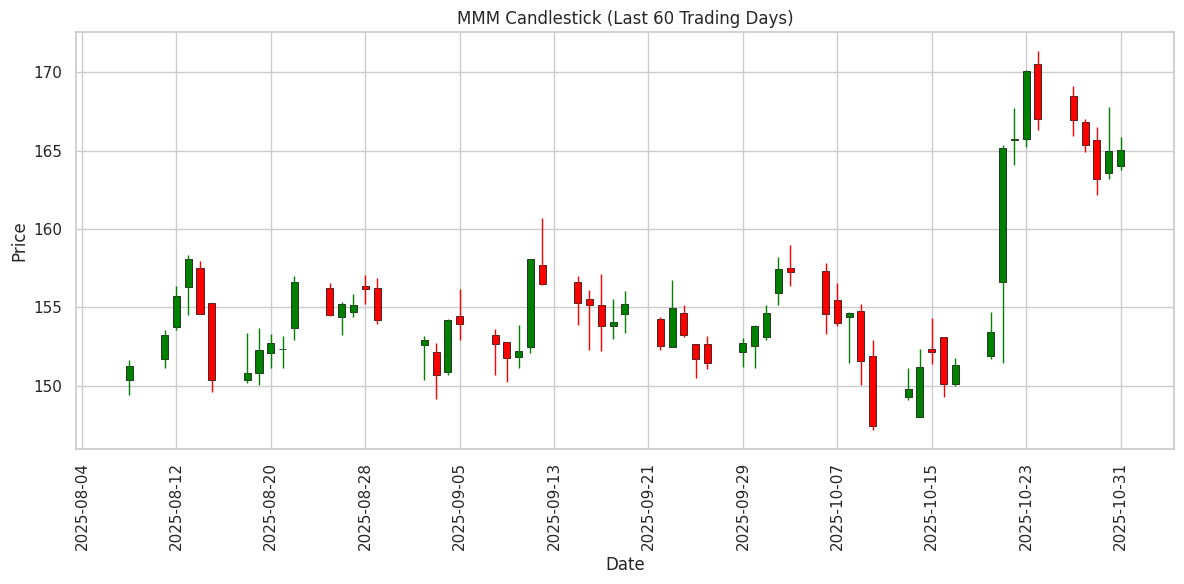

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

# width of the candlestick body in days
body_width = 0.6  # adjust (e.g., 0.5 - 0.8) to change bar thickness

for _, r in mmm.iterrows():
  o = r['Open']; c = r['Close']; h = r['High']; l = r['Low']
  color = 'green' if c >= o else 'red'
  x = r['Date']
  ax.vlines(x, l, h, color=color, linewidth=1)
  lower = min(o, c)
  height = abs(c - o)
  ax.add_patch(
    plt.Rectangle(
      (x - pd.Timedelta(days=body_width / 2), lower),
      pd.Timedelta(days=body_width),
      height if height != 0 else 0.0001,  # ensure visible even if open == close
      facecolor=color,
      edgecolor='black',
      linewidth=0.5
    )
  )

ax.set_title('MMM Candlestick (Last 60 Trading Days)')
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(plt.MaxNLocator(12))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Closing prices

To get closing prices of a few stocks, following command can be used:

In [18]:
first10 = rawdata.loc[:, idx['Close', ['MMM', 'MRK', 'PFE', 'PG', 'JNJ']]].tail(60)
first10.head()

Value            Close                                              
Symbol             MMM        MRK        PFE          PG         JNJ
Date                                                                
2025-08-08  151.263321  79.223618  23.756721  151.369232  170.077271
2025-08-11  153.246613  78.575607  23.756721  152.818741  170.558090
2025-08-12  155.752869  78.840706  23.824377  152.927200  169.537598
2025-08-13  158.071640  81.206902  24.317295  153.242752  171.146805
2025-08-14  154.568802  81.255997  24.268970  151.596039  171.441162

* Stacking transforms data into long-format:  
    _Note: unstack does the opposite_

In [19]:
healthcare = first10.stack('Symbol', future_stack=True)
healthcare

Value                   Close
Date       Symbol            
2025-08-08 MMM     151.263321
           MRK      79.223618
           PFE      23.756721
           PG      151.369232
           JNJ     170.077271
...                       ...
2025-10-31 MMM     165.047043
           MRK      85.251358
           PFE      23.824377
           PG      149.309891
           JNJ     186.685944

[300 rows x 1 columns]

## Data Cleaning

### Count missing values

* Inspect missing values:  

In [20]:
rawdata['Close'].isna().sum(axis=0)

Symbol
AAPL    0
AXP     0
BA      0
BAC     0
CAT     0
CSCO    0
CVX     0
DD      0
DIS     0
GE      0
HD      0
HPQ     0
IBM     0
INTC    0
JNJ     0
JPM     0
KO      0
MCD     0
MMM     0
MRK     0
MSFT    0
PFE     0
PG      0
T       0
TRV     0
VZ      0
WMT     0
XOM     0
dtype: int64

In [21]:
anymissing = rawdata['Close'].isna().any(axis=1)
rawdata.loc[anymissing]

Empty DataFrame
Columns: [(Close, AAPL), (Close, AXP), (Close, BA), (Close, BAC), (Close, CAT), (Close, CSCO), (Close, CVX), (Close, DD), (Close, DIS), (Close, GE), (Close, HD), (Close, HPQ), (Close, IBM), (Close, INTC), (Close, JNJ), (Close, JPM), (Close, KO), (Close, MCD), (Close, MMM), (Close, MRK), (Close, MSFT), (Close, PFE), (Close, PG), (Close, T), (Close, TRV), (Close, VZ), (Close, WMT), (Close, XOM), (High, AAPL), (High, AXP), (High, BA), (High, BAC), (High, CAT), (High, CSCO), (High, CVX), (High, DD), (High, DIS), (High, GE), (High, HD), (High, HPQ), (High, IBM), (High, INTC), (High, JNJ), (High, JPM), (High, KO), (High, MCD), (High, MMM), (High, MRK), (High, MSFT), (High, PFE), (High, PG), (High, T), (High, TRV), (High, VZ), (High, WMT), (High, XOM), (Low, AAPL), (Low, AXP), (Low, BA), (Low, BAC), (Low, CAT), (Low, CSCO), (Low, CVX), (Low, DD), (Low, DIS), (Low, GE), (Low, HD), (Low, HPQ), (Low, IBM), (Low, INTC), (Low, JNJ), (Low, JPM), (Low, KO), (Low, MCD), (Low, MMM), (Low, MRK), (Low, MSFT), (Low, PFE), (Low, PG), (Low, T), (Low, TRV), (Low, VZ), (Low, WMT), (Low, XOM), (Open, AAPL), (Open, AXP), (Open, BA), (Open, BAC), (Open, CAT), (Open, CSCO), (Open, CVX), (Open, DD), (Open, DIS), (Open, GE), (Open, HD), (Open, HPQ), (Open, IBM), (Open, INTC), (Open, JNJ), (Open, JPM), ...]
Index: []

[0 rows x 140 columns]

## Data Cleaning

* Double check: did we remove all missing values?

In [22]:
(rawdata.isna().sum()>0).any()

np.False_

* Reset symbols to what is in `data` variable

In [23]:
symbols = symbols.loc[rawdata.columns.levels[1].to_list()]
symbols

,name
code,
AAPL,Apple Inc (AAPL)
AXP,American Express Co. (AXP)
BA,The Boeing Co. (BA)
BAC,Bank of America Corp. (BAC)
CAT,Caterpillar Inc. (CAT)
CSCO,Cisco Systems Inc. (CSCO)
CVX,Chevron Corporation (CVX)
DD,E.I. du Pont de Nemours and Co. (DD)
DIS,Disney (Walt) Co. (The) (DIS)


In [24]:
rawdata.head()

Value          Close                                                         \
Symbol          AAPL        AXP         BA        BAC        CAT       CSCO   
Date                                                                          
2000-01-03  0.838496  32.251965  25.940285  12.426222  12.544689  34.961006   
2000-01-04  0.767802  31.034170  25.899942  11.688671  12.383454  32.999626   
2000-01-05  0.779038  30.245935  27.513649  11.816939  12.673682  32.898521   
2000-01-06  0.711621  30.862143  27.796040  12.827075  13.318659  32.352570   
2000-01-07  0.745330  31.311460  28.602888  12.490361  13.754023  34.253284   

Value                                                    ...   Volume  \
Symbol            CVX         DD        DIS          GE  ...      MMM   
Date                                                     ...            
2000-01-03  15.721488  11.746678  22.583426  129.626480  ...  2599386   
2000-01-04  15.721488  11.425600  23.906303  124.441414  ...  3245705   
2000-01-05  16.003489  11.796491  24.898462  124.225395  ...  4424482   
2000-01-06  16.684986  12.128633  23.906303  125.886185  ...  7147057   
2000-01-07  16.978733  12.399887  23.528341  130.760727  ...  4905035   

Value                                                                         \
Symbol           MRK      MSFT       PFE       PG         T     TRV       VZ   
Date                                                                           
2000-01-03   6265782  53228400  12873345  4275000   7668476  336400  4663843   
2000-01-04   7894689  54119000  14208974  4270800   9497846  494400  5005878   
2000-01-05   7963018  64059600  12981591  5098400  12035160  736000  6368681   
2000-01-06   4989004  54976600  11115273  6524200   9471366  660400  4705763   
2000-01-07  10871218  62013600  17962163  9832000   7792534  594700  5043907   

Value                           
Symbol           WMT       XOM  
Date                            
2000-01-03  25109700  13458200  
2000-01-04  20235300  14510800  
2000-01-05  21056100  17485000  
2000-01-06  19633500  19461600  
2000-01-07  23930700  16603800  

[5 rows x 140 columns]

#### Closing Prices

* [Closing prices](https://help.yahoo.com/kb/SLN28256.html) accounts for splits, etc

In [25]:
closedata = rawdata['Close']
closedata.head()

Symbol,AAPL,AXP,BA,BAC,CAT,CSCO,CVX,DD,DIS,GE,...,MMM,MRK,MSFT,PFE,PG,T,TRV,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,0.838496,32.251965,25.940285,12.426222,12.544689,34.961006,15.721488,11.746678,22.583426,129.626480,...,19.257401,25.212040,35.520370,11.458941,26.833694,6.250891,17.387356,15.310869,14.210652,17.141266
2000-01-04,0.767802,31.034170,25.899942,11.688671,12.383454,32.999626,15.721488,11.425600,23.906303,124.441414,...,18.492203,24.326590,34.320496,11.032041,26.317366,5.885149,17.156843,14.815954,13.678917,16.812946
2000-01-05,0.779038,30.245935,27.513649,11.816939,12.673682,32.898521,16.003489,11.796491,24.898462,124.225395,...,19.027840,25.281942,34.682373,11.211789,25.816669,5.976582,17.025124,15.310869,13.399763,17.729515
2000-01-06,0.711621,30.862143,27.796040,12.827075,13.318659,32.352570,16.684986,12.128633,23.906303,125.886185,...,20.558220,25.491673,33.520576,11.616220,27.005810,5.860785,17.354420,15.233102,13.545981,18.646091
2000-01-07,0.745330,31.311460,28.602888,12.490361,13.754023,34.253284,16.978733,12.399887,23.528341,130.760727,...,20.966330,27.938316,33.958630,12.402616,29.165010,5.911017,18.045969,15.120622,14.569580,18.591368


## Data Preprocessing

### Log returns from stock prices

* Data is price per share
* We need daily returns from the prices
* Given the prices $P_t$ and $P_{t-1}$ for time $t$, the return is, 
$$ R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1 $$

* Approximation $\log(1+x)\approx x$ is good when $x$ is small
* Since daily returns of stocks are small, calculate as returns,
$$ r_t = \log(1 + R_t) = \log\left(\frac{P_t}{P_{t-1}}\right) = \log(P_t) - \log(P_{t-1})$$
So, in order to compute the log-returns, compute the difference of log prices:

In [26]:
logret = np.log(closedata).diff()
logret.head()

Symbol,AAPL,AXP,BA,BAC,CAT,CSCO,CVX,DD,DIS,GE,...,MMM,MRK,MSFT,PFE,PG,T,TRV,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,-0.088078,-0.038490,-0.001556,-0.061189,-0.012936,-0.057737,0.000000,-0.027714,0.056926,-0.040822,...,-0.040546,-0.035752,-0.034364,-0.037967,-0.019429,-0.060292,-0.013346,-0.032858,-0.038136,-0.019340
2000-01-05,0.014527,-0.025727,0.060441,0.010914,0.023166,-0.003069,0.017778,0.031946,0.040664,-0.001737,...,0.028554,0.038520,0.010489,0.016162,-0.019209,0.015417,-0.007707,0.032858,-0.020619,0.053082
2000-01-06,-0.090514,0.020168,0.010211,0.082024,0.049638,-0.016734,0.041703,0.027767,-0.040664,0.013281,...,0.077358,0.008261,-0.034072,0.035437,0.045032,-0.019565,0.019157,-0.005092,0.010853,0.050406
2000-01-07,0.046281,0.014454,0.028614,-0.026601,0.032165,0.057089,0.017452,0.022118,-0.015936,0.037991,...,0.019657,0.091647,0.012984,0.065505,0.076918,0.008534,0.039075,-0.007411,0.072846,-0.002939


* First time period is NaN since there is no data corresponding to $-1$.

* Note that $100\cdot r_t$% represent daily percentage returns.

### Estimate expected returns

Estimate the daily expected returns by computing the means:

In [27]:
mu = logret[1:].mean()
mu

Symbol
AAPL    0.000889
AXP     0.000371
BA      0.000315
BAC     0.000224
CAT     0.000589
CSCO    0.000113
CVX     0.000352
DD      0.000163
DIS     0.000246
GE      0.000134
HD      0.000354
HPQ     0.000129
IBM     0.000257
INTC    0.000074
JNJ     0.000320
JPM     0.000401
KO      0.000248
MCD     0.000407
MMM     0.000331
MRK     0.000188
MSFT    0.000412
PFE     0.000113
PG      0.000264
T       0.000210
TRV     0.000421
VZ      0.000144
WMT     0.000302
XOM     0.000290
dtype: float64

### Estimate covariance matrix (volatility structure)

Estimate the covarince matrix of returns:

In [28]:
cov_sample = logret.cov()
cov_sample

Symbol,AAPL,AXP,BA,BAC,CAT,CSCO,CVX,DD,DIS,GE,...,MMM,MRK,MSFT,PFE,PG,T,TRV,VZ,WMT,XOM
Symbol,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000632,0.000203,0.000163,0.000211,0.000179,0.000260,0.000116,0.000164,0.000167,0.000177,...,0.000122,0.000084,0.000222,0.000085,0.000065,0.000103,0.000124,0.000089,0.000095,0.000109
AXP,0.000203,0.000498,0.000251,0.000408,0.000246,0.000226,0.000191,0.000259,0.000239,0.000275,...,0.000178,0.000124,0.000195,0.000134,0.000095,0.000151,0.000220,0.000127,0.000113,0.000174
BA,0.000163,0.000251,0.000495,0.000249,0.000206,0.000168,0.000175,0.000226,0.000195,0.000232,...,0.000149,0.000098,0.000157,0.000110,0.000078,0.000116,0.000160,0.000089,0.000089,0.000164
BAC,0.000211,0.000408,0.000249,0.000743,0.000276,0.000234,0.000210,0.000296,0.000235,0.000309,...,0.000195,0.000130,0.000191,0.000148,0.000102,0.000164,0.000247,0.000134,0.000110,0.000188
CAT,0.000179,0.000246,0.000206,0.000276,0.000407,0.000182,0.000185,0.000259,0.000178,0.000221,...,0.000177,0.000100,0.000156,0.000110,0.000077,0.000115,0.000157,0.000097,0.000092,0.000173
CSCO,0.000260,0.000226,0.000168,0.000234,0.000182,0.000516,0.000125,0.000183,0.000191,0.000199,...,0.000139,0.000089,0.000237,0.000104,0.000074,0.000121,0.000145,0.000112,0.000106,0.000119
CVX,0.000116,0.000191,0.000175,0.000210,0.000185,0.000125,0.000300,0.000184,0.000144,0.000164,...,0.000121,0.000103,0.000121,0.000102,0.000065,0.000106,0.000145,0.000089,0.000064,0.000240
DD,0.000164,0.000259,0.000226,0.000296,0.000259,0.000183,0.000184,0.000478,0.000193,0.000230,...,0.000186,0.000117,0.000157,0.000125,0.000097,0.000126,0.000171,0.000104,0.000100,0.000171
DIS,0.000167,0.000239,0.000195,0.000235,0.000178,0.000191,0.000144,0.000193,0.000370,0.000194,...,0.000136,0.000094,0.000162,0.000100,0.000073,0.000120,0.000141,0.000107,0.000092,0.000136


### Visualization

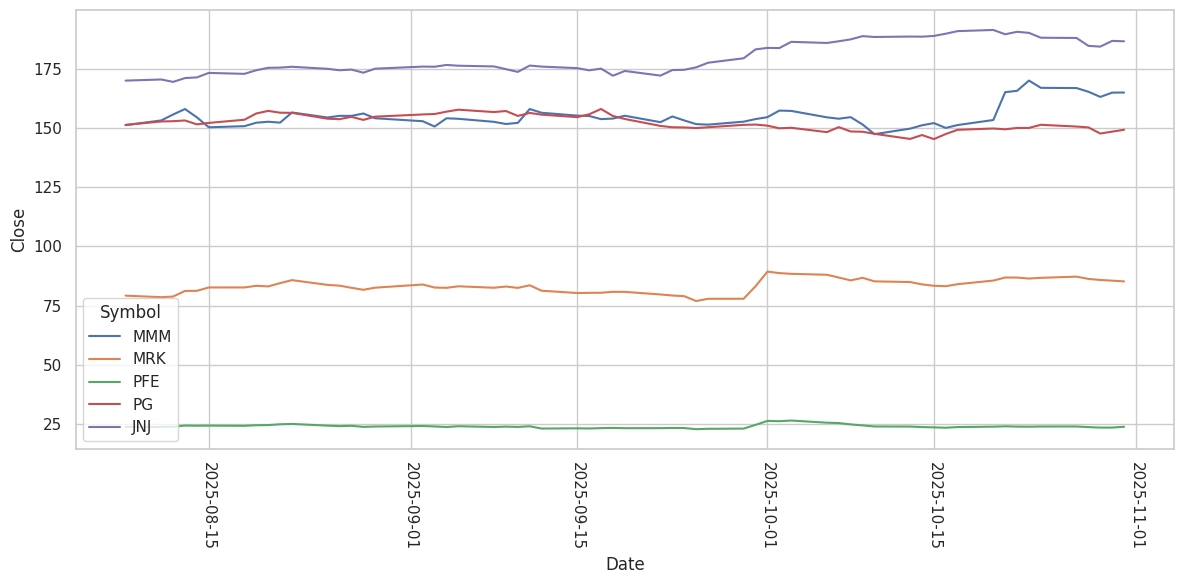

In [29]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=healthcare, x='Date', y='Close', hue='Symbol')
plt.xticks(rotation=-90)
plt.tight_layout()
plt.show()


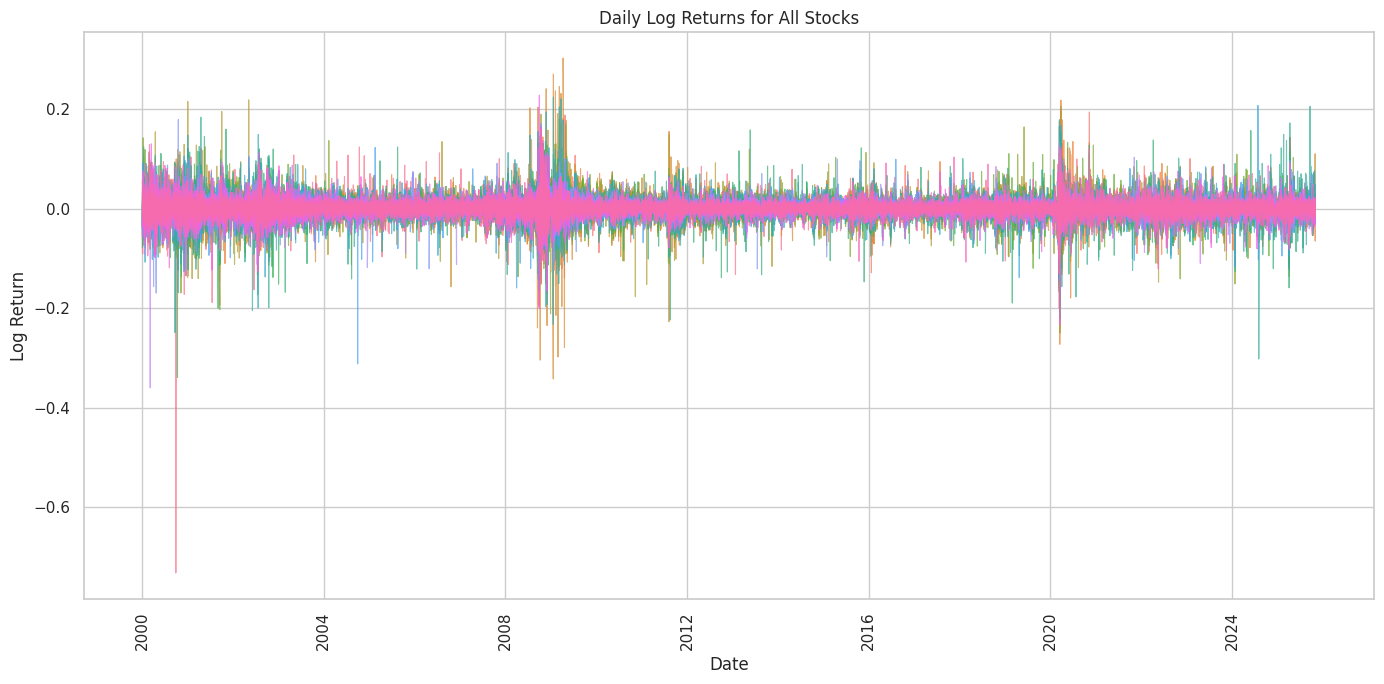

In [30]:
# Plot daily log returns for all stocks
logret_long = logret.reset_index().melt(
  id_vars='Date', var_name='Symbol', value_name='LogReturn'
)

plt.figure(figsize=(14, 7))
sns.lineplot(
  data=logret_long,
  x='Date',
  y='LogReturn',
  hue='Symbol',
  linewidth=0.8,
  alpha=0.7,
  legend=False
)
plt.title('Daily Log Returns for All Stocks')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Calculate Portfolio Allocation

### Minimum Variance Portfolio

* $\Sigma$ matrix is all that is specified
* $\Sigma$ characterizes the market
* Minimize variance of portfolio $R_p$

In [31]:
s, _ = cov_sample.shape # calculated from data

w_mvp = cvx.Variable(s) # variables
risk = cvx.quad_form(w_mvp, cov_sample.values)  # objective function
prob = cvx.Problem(cvx.Minimize(risk), # optimization problem 
               [cvx.sum(w_mvp) == 1])      # fully invested portfolio constraint
prob.solve()

np.float64(8.182722276105023e-05)

In [32]:
w_mvp.value

array([ 0.01652724, -0.06677747, -0.0055687 , -0.01420942,  0.00303489,
       -0.0191693 ,  0.03920491, -0.0398509 ,  0.0165212 , -0.00538892,
       -0.02358273,  0.01211549,  0.09040332, -0.01447757,  0.21424807,
       -0.02886979,  0.14256068,  0.1468334 ,  0.06653735,  0.01455828,
        0.02968838,  0.02761719,  0.12084112,  0.00462431,  0.01039099,
        0.09993254,  0.13561118,  0.02664427])

* Positive weights indicate long positions
* Negative weights indicate [short positions](https://en.wikipedia.org/wiki/Short_(finance))
* Must sum to 1 (constraint)

* Other portfolio optimization variations:  
    http://nbviewer.jupyter.org/github/cvxgrp/cvx_short_course/blob/master/applications/portfolio_optimization.ipynb

* `cvxpy` package makes it easy to solve many types of problems easily

### MVP with target return
* Portfolio allocation problem with target expected return constraint:

$$ \min_{\mathbf{x}\in\mathbb{R}^s}\ \ \mathbf{x}^\top \Sigma \mathbf{x}\\
\text{subject to }\boldsymbol{\mu}^\top \mathbf{x}\geq \mu^* \text{, and } \mathbf{1}^\top \mathbf{x} = 1,$$

* Expected returns, $\boldsymbol{\mu}$, is estimated from data (also $\Sigma$)
* Investor specifies target return $\mu^*$

In [33]:
s,_ = cov_sample.shape

w_tgt = cvx.Variable(s)
risk = cvx.quad_form(w_tgt, cov_sample.values)
prob = cvx.Problem(cvx.Minimize(risk), 
               [
                   cvx.sum(w_tgt) == 1,
                   mu.values@w_tgt >= 0.001,
                   # w_tgt >= 0
               ]) 
prob.solve()

np.float64(0.000255829867429155)

In [34]:
w_tgt.value

array([ 0.37727035,  0.0103587 ,  0.00531841, -0.19475584,  0.38319343,
       -0.19932099,  0.15270735, -0.22931515, -0.04446317, -0.22543986,
       -0.0039981 , -0.12687129,  0.07198675, -0.20353504,  0.43703254,
        0.20627457,  0.00312653,  0.32205513,  0.14227995, -0.07175215,
        0.18423665, -0.21650356,  0.10500878,  0.0260234 ,  0.16675811,
       -0.11353915,  0.12224829, -0.08638463])

* Higher target return achieved with more short positions
* Constraint: $\boldsymbol{\mu}^\top \mathbf{w}=0.001$
* Constraint: $\mathbf{1}^\top \mathbf{w}=1$.

In [35]:
w_tgt.value.sum()

np.float64(1.0)

In [36]:
np.dot(mu.values,w_tgt.value)

np.float64(0.001)

## Portfolio returns (no backtesting)

* Investing 1 dollar in a stock with 3% return over one time period makes me 3 cents:  
    $$\$1 \cdot (1 + 0.03) = 1.03$$
    
* Investing a portfolio of worth $A_0$ dollars results in $A_1$ in the next time period:
    $$ A_1 = A_0 \left(1+\mathbf{r}_t^\top \mathbf{w}_t\right), $$
    where elements of $\mathbf{r}_t$ are returns at time $t$ and $\mathbf{w}_t$ is portfolio allocation

* Take allocation `w.value` and compute portfolio returns using historical returns: `logret`.

In [37]:
# bfill to handle NaN in first row of log returns

pf_ret_mvp = np.dot(logret.bfill().values, w_mvp.value) 
pf_ret_tgt = np.dot(logret.bfill().values, w_tgt.value)

* To compute portfolio return for each time period, multiply the (6498-row-by-28-column) matrix of returns `logret.bfill().values` by `w_*.values` (28-element-vector) 

* Portfolio value can be computed as a cumumlative product defined by
  $$
  A_t = A_0 \prod_{\tau=1}^{t}\left(1+\mathbf{r}_{\tau}^{\top}\mathbf{w}_{\tau}\right), 
  $$
  where initial portfolio value is $A_0$.

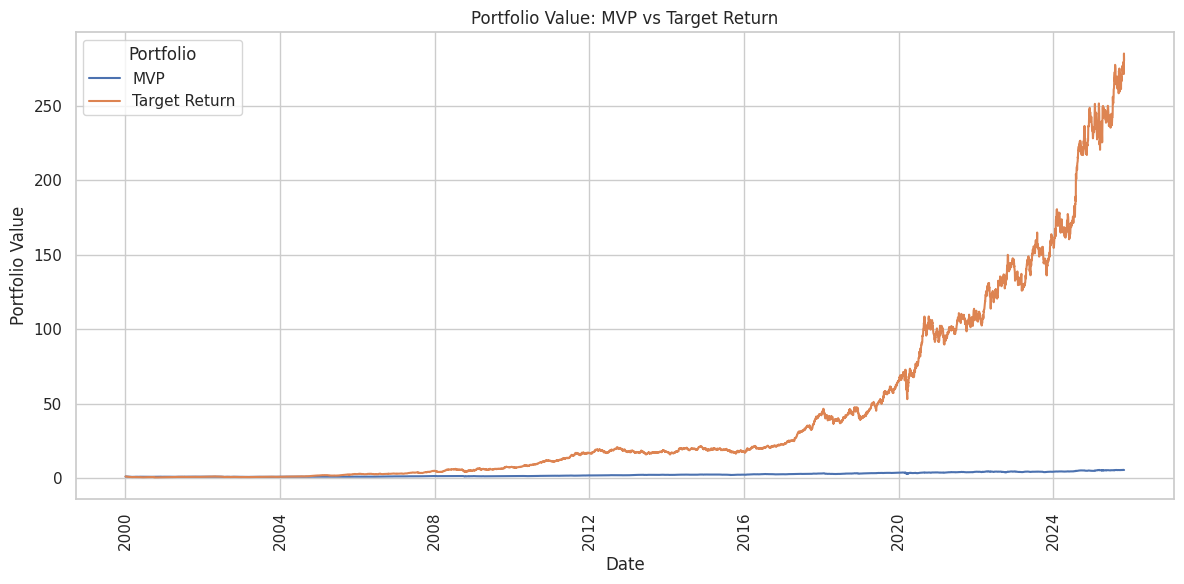

In [38]:
pf_val_mvp = (1 + pf_ret_mvp).cumprod()
pf_val_tgt = (1 + pf_ret_tgt).cumprod()

portfolio_values = pd.DataFrame({
    'MVP': pf_val_mvp,
    'Target Return': pf_val_tgt
}, index=logret.index)

plot_df = portfolio_values.reset_index().melt(
  id_vars='Date',
  var_name='Portfolio',
  value_name='Portfolio Value'
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Date', y='Portfolio Value', hue='Portfolio')
plt.title('Portfolio Value: MVP vs Target Return')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

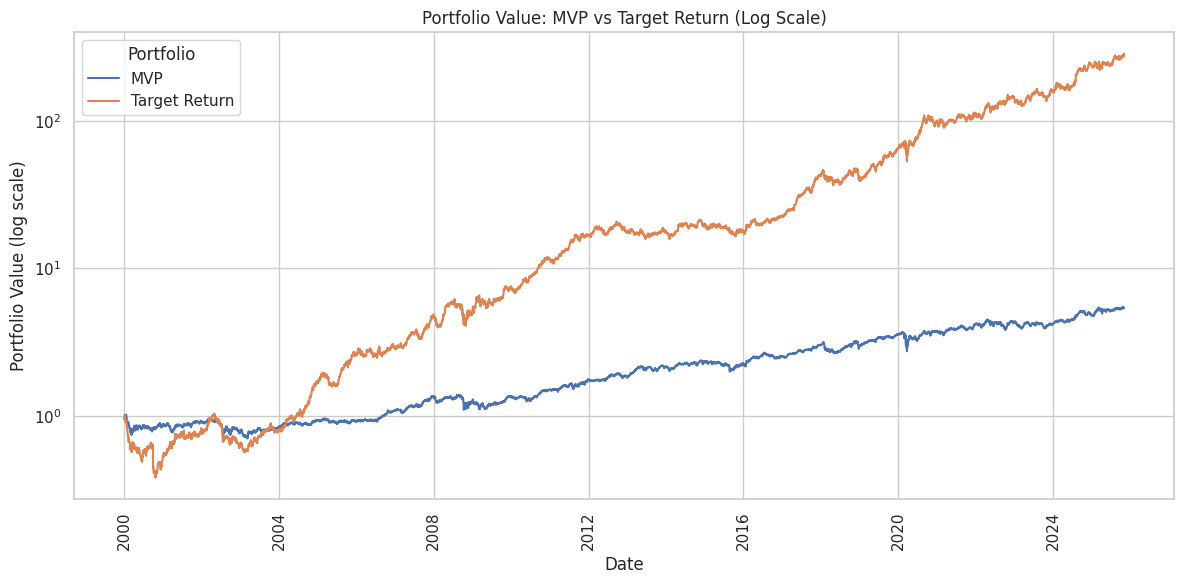

In [39]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Date', y='Portfolio Value', hue='Portfolio')
plt.yscale('log')
plt.title('Portfolio Value: MVP vs Target Return (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (log scale)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The analysis shows that 1 dollar invested in 2000 would be 285 dollars today. 

### Summarize results

In [40]:
def annualize_returns(returns, trading_days=252):
  # Convert daily returns to annual returns assuming 252 trading days per year
  return (1 + returns)**trading_days - 1

def daily_returns(annual_return, trading_days=252):
  # Convert annual returns to daily returns assuming 252 trading days per year
  return np.exp(np.log(1 + annual_return) / trading_days) - 1

In [41]:
# Summary table: average and stddev for requested return groups

component_mean_returns = logret.mean(axis=0)                 # daily mean return per stock
component_std_returns = logret.std(axis=0, ddof=1)           # daily stddev per stock

summary_table = pd.DataFrame({
  "Average Return (Annualized)": [
    annualize_returns(component_mean_returns).mean(),        # average annualized stock mean returns
    annualize_returns(np.mean(pf_ret_mvp)),                  # annualized MVP mean return
    annualize_returns(np.mean(pf_ret_tgt))                   # annualized target-return portfolio mean return
  ],
  "StdDev (Annualized)": [
    component_std_returns.mean() * np.sqrt(252),             # average annualized stock volatility
    np.std(pf_ret_mvp, ddof=1) * np.sqrt(252),               # annualized MVP volatility
    np.std(pf_ret_tgt, ddof=1) * np.sqrt(252)                # annualized target-return volatility
  ]
}, index=[
  "Component Stocks (Mean Returns)",
  "MVP Portfolio",
  "Target Return Portfolio"
])

summary_table

,Average Return (Annualized),StdDev (Annualized)
Component Stocks (Mean Returns),0.078086,0.298381
MVP Portfolio,0.078411,0.143667
Target Return Portfolio,0.285454,0.253918


The summary table compares annualized return and volatility across three portfolios:

- **Component Stocks (Mean Returns)**:  
  Average annual return is about **7.81%** with annualized volatility around **29.84%**.

- **MVP Portfolio** (minimum-variance):  
  Average annual return is about **7.84%**, nearly the same as individual stocks on average, but with much lower volatility (**14.37%**).  
  This suggests strong **diversification benefits**.

- **Target Return Portfolio**:  
  Average annual return is much higher at about **28.55%**, with volatility **25.39%**.  
  This indicates a more aggressive allocation (likely involving short positions), with higher risk and higher reward.

Overall, the MVP appears most efficient for risk reduction, while the target-return portfolio pursues substantially higher return at increased risk.

## Reality check

However, above analysis is not realistic. 

Why not? What aspects were unrealistic?

1. We didn't take time into consideration: e.g. estimation of $\Sigma$ and selecting $\mathbf{w}$.
1. We are investing with knowledge of the future returns!
1. We did not take into account transaction costs (we will have to) 
1. We did not take into account shorting requires borrowing of money
1. Is investing in stocks better than leaving our money in a savings account? What is the interest rate?

Sharpe ratio tries to quantify the added benefit, i.e., excess returns, of investing in the volatile market by accounting for the volatility:
$$\text{Sharpe ratio}=\frac{E\left[R_{p}-R_{f}\right]}{\sigma_{p}}$$
where $R_f$ is the risk-free rate.


## Backtesting

Backtesting evaluates how a portfolio strategy would have performed **historically** using only information available at each decision date.  
It helps answer: *If this allocation rule had been followed in real time, what returns and risk would have resulted?*

### Core ideas

- **Estimation window (lookback):** use the most recent past data (e.g., 300 days) to estimate expected returns $ \mu $ and covariance $ \Sigma $.
- **Portfolio construction:** solve an optimization problem (here, minimum variance) to get weights $w$.
- **Holding period (horizon):** keep those weights fixed for the next period (e.g., 50 days).
- **Rebalancing:** repeat this process at a fixed interval (e.g., every 50 days).
- **Performance aggregation:** stitch together all out-of-sample period returns into one return series, then compute cumulative wealth and summary metrics.

### Functions used in this notebook

- **`estimate_moments(returns_df, cov_fn=None)`**  
  Computes $ \hat{\mu} $ and $ \hat{\Sigma} $ from the rolling window.  
  - Default covariance: sample covariance.  
  - Optional `cov_fn`: plug-in estimator (e.g., Ledoit–Wolf, Graphical Lasso).

- **`compute_min_var_weights(mu_vec, cov_mat, target_return=None, long_only=False, ridge=1e-6, solver_opts=None)`**  
  Solves:
  $$
  \min_w \; w^\top \Sigma w
  \quad \text{s.t.} \quad \mathbf{1}^\top w = 1
  $$
  with optional constraints:
  - $ \mu^\top w \ge \text{target\_return} $
  - $ w \ge 0 $ if long-only.  
  A small ridge term is added to the diagonal of $ \Sigma $ for numerical stability.

- **`compute_portfolio_returns(returns_df, weights)`**  
  Aligns assets and computes daily portfolio returns via matrix multiplication:
  $$
  r_{p,t} = r_t^\top w
  $$

- **`rolling_backtest(...)`**  
  Orchestrates the full loop:
  1. take a lookback window,
  2. estimate moments,
  3. solve for weights,
  4. apply weights to the next horizon,
  5. move forward by rebalance step,
  6. collect returns and rebalance-date weights.

### How the backtests are run here

Three minimum-variance backtests are executed on `logret` with:
- `lookback=300`, `horizon=50`, `rebalance=50`,
- `long_only=False` (shorting allowed).

They differ only in covariance estimation:
1. **Sample covariance** (`cov_fn=None`)
2. **Ledoit–Wolf shrinkage**
3. **Graphical Lasso**

In [42]:
# Rolling backtest with 300-day lookback and 50-day rebalance horizon

def estimate_moments(returns_df, cov_fn=None):
  """
  Estimate mean vector and covariance matrix from a returns window.
  - returns_df: DataFrame of daily returns (rows: dates, cols: assets)
  - cov_fn: optional function taking returns_df and returning a covariance matrix
  """
  window = returns_df.dropna()
  mu_hat = window.mean()
  if cov_fn is None:
    cov_hat = window.cov()
  else:
    cov_hat = cov_fn(window)
    # Convert to DataFrame with consistent indexing if needed
    if not isinstance(cov_hat, pd.DataFrame):
      cov_hat = pd.DataFrame(cov_hat, index=window.columns, columns=window.columns)
  return mu_hat, cov_hat


def compute_min_var_weights(mu_vec, cov_mat, target_return=None, long_only=False, ridge=1e-6, solver_opts=None):
  """
  Solve for portfolio weights minimizing variance:
    min w' Σ w
    s.t. 1' w = 1
       μ' w >= target_return (optional)
       w >= 0 (if long_only)
  - mu_vec: pd.Series indexed by asset
  - cov_mat: pd.DataFrame with same index/columns
  - ridge: small diagonal loading for numerical stability
  """
  cols = mu_vec.index
  Sigma = cov_mat.copy()
  # numerical stabilizer
  Sigma.values[range(Sigma.shape[0]), range(Sigma.shape[0])] += ridge

  n = len(cols)
  w_var = cvx.Variable(n)
  constraints = [cvx.sum(w_var) == 1]
  if long_only:
    constraints.append(w_var >= 0)
  if target_return is not None:
    constraints.append(mu_vec.values @ w_var >= float(target_return))

  objective = cvx.Minimize(cvx.quad_form(w_var, Sigma.values))
  prob_local = cvx.Problem(objective, constraints)
  prob_local.solve(**(solver_opts or {}))
  w_val = w_var.value
  if w_val is None or np.any(np.isnan(w_val)):
    raise RuntimeError("Solver returned invalid weights")
  weights = pd.Series(w_val, index=cols, name='weight')
  return weights


def compute_portfolio_returns(returns_df, weights):
  """
  Compute daily portfolio returns given returns matrix and weights.
  - returns_df: DataFrame (dates x assets)
  - weights: pd.Series indexed by assets
  """
  # align columns
  common = [c for c in returns_df.columns if c in weights.index]
  if len(common) == 0:
    return pd.Series([], dtype=float)
  w = weights.loc[common]
  R = returns_df[common]
  # dot product per day
  return R.dot(w)


def rolling_backtest(returns,
       lookback=300,
       rebalance=50,
       cov_fn=None,
       target_return=None,
       long_only=True,
       ridge=1e-6,
       solver_opts=None):
  """
  Rolling backtest:
  - Use past `lookback` days to estimate mu, Sigma
  - Invest for next `rebalance` days with fixed weights
  - Rebalance every `rebalance` days
  Returns:
  dict with:
  'returns': pd.Series of daily portfolio returns over backtest
  'weights': pd.DataFrame of weights per rebalance date (rows=dates, cols=assets)
  """
  dates = returns.index
  n = len(dates)
  out_returns_parts = []
  weights_records = []

  start = lookback
  while start < n:
    end_invest = min(start + rebalance, n)

    window = returns.iloc[start - lookback:start]
    mu_hat, cov_hat = estimate_moments(window, cov_fn=cov_fn)
    w_hat = compute_min_var_weights(mu_hat, cov_hat,
            target_return=target_return,
            long_only=long_only,
            ridge=ridge,
            solver_opts=solver_opts)

    period_rets = returns.iloc[start:end_invest]
    port_rets = compute_portfolio_returns(period_rets, w_hat)
    out_returns_parts.append(port_rets)

    # store weights at the rebalance date
    w_row = w_hat.reindex(returns.columns).fillna(0.0)
    w_row.name = dates[start]
    weights_records.append(w_row)

    # advance to next rebalance
    start += rebalance

  out_returns = pd.concat(out_returns_parts).sort_index()
  weights_df = pd.DataFrame(weights_records)
  return {'returns': out_returns, 'weights': weights_df}


In [43]:
# Run the requested backtest on the existing `logret` DataFrame
bt = rolling_backtest(
  logret,
  lookback=300,
  rebalance=50,
  cov_fn=None,          # default: sample covariance
  target_return=None,   # pure minimum-variance
  long_only=False,       # set False to allow shorting
  ridge=1e-6,
)

bt_returns = bt['returns']
bt_weights = bt['weights']

# Example outputs: cumulative growth from log returns
bt_wealth = np.exp(bt_returns.cumsum())
bt_results = {
  'final_wealth': float(bt_wealth.iloc[-1]) if len(bt_wealth) else np.nan,
  'mean_daily_return': float(bt_returns.mean()) if len(bt_returns) else np.nan,
  'std_daily_return': float(bt_returns.std()) if len(bt_returns) else np.nan,
}

bt_results

{'final_wealth': 5.631302760266601,
 'mean_daily_return': 0.0002788546001167084,
 'std_daily_return': 0.009221037245451076}

In [44]:
# perform backtest using ledoit-wolf shrinkage covariance estimator
from sklearn.covariance import LedoitWolf
def ledoit_wolf_cov(returns_df):
  lw = LedoitWolf().fit(returns_df.dropna().values)
  cov_est = lw.covariance_
  return pd.DataFrame(cov_est, index=returns_df.columns, columns=returns_df.columns)

bt_lw = rolling_backtest(
  logret,
  lookback=300,
  rebalance=50,
  cov_fn=ledoit_wolf_cov,
  target_return=None,
  long_only=False,
  ridge=1e-6,
)
bt_lw_returns = bt_lw['returns']
bt_lw_wealth = np.exp(bt_lw_returns.cumsum())
bt_lw_results = {
  'final_wealth': float(bt_lw_wealth.iloc[-1]) if len(bt_lw_wealth) else np.nan,
  'mean_daily_return': float(bt_lw_returns.mean()) if len(bt_lw_returns) else np.nan,
  'std_daily_return': float(bt_lw_returns.std()) if len(bt_lw_returns) else np.nan,
}

bt_lw_results

{'final_wealth': 5.843640961231176,
 'mean_daily_return': 0.00028482640445952307,
 'std_daily_return': 0.009095053949877037}

In [45]:
# perform backtest using graphical lasso covariance estimator
from sklearn.covariance import GraphicalLasso
def graphical_lasso_cov(returns_df, alpha=0.01):
  gl = GraphicalLasso(alpha=alpha).fit(returns_df.dropna().values)
  cov_est = gl.covariance_
  return pd.DataFrame(cov_est, index=returns_df.columns, columns=returns_df.columns)

bt_gl = rolling_backtest(
  logret,
  lookback=300,
  rebalance=50,
  cov_fn=graphical_lasso_cov,
  target_return=None,
  long_only=False,
  ridge=1e-6,
)
bt_gl_returns = bt_gl['returns']
bt_gl_wealth = np.exp(bt_gl_returns.cumsum())
bt_gl_results = {
  'final_wealth': float(bt_gl_wealth.iloc[-1]) if len(bt_gl_wealth) else np.nan,
  'mean_daily_return': float(bt_gl_returns.mean()) if len(bt_gl_returns) else np.nan,
  'std_daily_return': float(bt_gl_returns.std()) if len(bt_gl_returns) else np.nan,
}

bt_gl_results

{'final_wealth': 7.132352928298541,
 'mean_daily_return': 0.00031697986188380294,
 'std_daily_return': 0.010463294345682314}

In [46]:
# perform backtest using ledoit-wolf shrinkage covariance estimator with target return
bt_lw_tgt = rolling_backtest(
  logret,
  lookback=300,
  rebalance=50,
  cov_fn=ledoit_wolf_cov,
  target_return=0.0007,  # ~0.07% daily return target equivalent to ~20% annual return
  long_only=False,
  ridge=1e-6,
)
bt_lw_tgt_returns = bt_lw_tgt['returns']
bt_lw_tgt_wealth = np.exp(bt_lw_tgt_returns.cumsum())
bt_lw_tgt_results = {
  'final_wealth': float(bt_lw_tgt_wealth.iloc[-1]) if len(bt_lw_tgt_wealth) else np.nan,
  'mean_daily_return': float(bt_lw_tgt_returns.mean()) if len(bt_lw_tgt_returns) else np.nan,
  'std_daily_return': float(bt_lw_tgt_returns.std()) if len(bt_lw_tgt_returns) else np.nan,
}

bt_lw_tgt_results


{'final_wealth': 6.947345833886005,
 'mean_daily_return': 0.00031273954376114416,
 'std_daily_return': 0.009307477996294418}

In [47]:
bt_gl_tgt = rolling_backtest(
  logret,
  lookback=300,
  rebalance=50,
  cov_fn=graphical_lasso_cov,
  target_return=0.0007,  # ~0.07% daily return target equivalent to ~20% annual return
  long_only=False,
  ridge=1e-6,
)
bt_gl_tgt_returns = bt_gl_tgt['returns']
bt_gl_tgt_wealth = np.exp(bt_gl_tgt_returns.cumsum())
bt_gl_tgt_results = {
  'final_wealth': float(bt_gl_tgt_wealth.iloc[-1]) if len(bt_gl_tgt_wealth) else np.nan,
  'mean_daily_return': float(bt_gl_tgt_returns.mean()) if len(bt_gl_tgt_returns) else np.nan,
  'std_daily_return': float(bt_gl_tgt_returns.std()) if len(bt_gl_tgt_returns) else np.nan,
}

bt_gl_tgt_results

{'final_wealth': 5.510629509943317,
 'mean_daily_return': 0.0002753596104013385,
 'std_daily_return': 0.009799537215631367}

### Annualized Backtest Summary


In [48]:
# Build annualized summary from existing backtest result dicts
bt_compare = pd.DataFrame(
  [bt_results, bt_lw_results, bt_gl_results, bt_lw_tgt_results, bt_gl_tgt_results],
  index=["Sample Covariance", "Ledoit-Wolf", "Graphical Lasso", "Ledoit-Wolf + Target Return", "Graphical Lasso + Target Return"]
)

bt_compare_annualized = pd.DataFrame({
  "Final Wealth": bt_compare["final_wealth"],
  "Annualized Return": np.exp(bt_compare["mean_daily_return"] * 252) - 1,
  "Annualized Volatility": bt_compare["std_daily_return"] * np.sqrt(252),
})

# Optional: percent formatting for readability
bt_compare_annualized_style = bt_compare_annualized.style.format({
  "Final Wealth": "{:.2f}",
  "Annualized Return": "{:.2%}",
  "Annualized Volatility": "{:.2%}",
})

bt_compare_annualized_style


,Final Wealth,Annualized Return,Annualized Volatility
Sample Covariance,5.63,7.28%,14.64%
Ledoit-Wolf,5.84,7.44%,14.44%
Graphical Lasso,7.13,8.32%,16.61%
Ledoit-Wolf + Target Return,6.95,8.20%,14.78%
Graphical Lasso + Target Return,5.51,7.19%,15.56%


In [49]:
!pip install bokeh

In [50]:
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool, DatetimeTickFormatter

# Plot the growth of the three portfolios
output_notebook()

series_map = {
  "Sample Covariance": (bt_wealth, "blue"),
  "Ledoit-Wolf": (bt_lw_wealth, "orange"),
  "Graphical Lasso": (bt_gl_wealth, "green"),
  "Ledoit-Wolf + Target Return": (bt_lw_tgt_wealth, "red"),
  "Graphical Lasso + Target Return": (bt_gl_tgt_wealth, "purple"),
}

p = figure(
  width=1000,
  height=600,
  x_axis_type="datetime",
  title="Portfolio Growth Over Time",
  tools="pan,wheel_zoom,box_zoom,reset,save",
)

renderers = []
for label, (series, color) in series_map.items():
  src = ColumnDataSource(
    data={
      "Date": series.index,
      "Growth": series.values,
      "Portfolio": [label] * len(series),
    }
  )
  r = p.line(
    x="Date",
    y="Growth",
    source=src,
    color=color,
    line_width=2,
    alpha=0.2,            # dim all traces by default
    hover_alpha=1.0,      # hovered trace pops out
    hover_line_width=4,
    legend_label=label,
    muted_alpha=0.05,     # optional: click legend to dim further
  )
  renderers.append(r)

hover = HoverTool(
  renderers=renderers,
  tooltips=[
    ("Portfolio", "@Portfolio"),
    ("Date", "@Date{%F}"),
    ("Cumulative Growth", "@Growth{0.000}")
  ],
  formatters={"@Date": "datetime"},
  mode="mouse",
)
p.add_tools(hover)

p.xaxis.axis_label = "Date"
p.yaxis.axis_label = "Cumulative Growth"
p.xaxis.formatter = DatetimeTickFormatter(years="%Y", months="%Y-%m", days="%Y-%m-%d")
p.legend.location = "top_left"
p.legend.click_policy = "mute"

show(p)

Loading BokehJS ...

In [51]:
store['logret'] = logret
store.close()